In [ ]:
!pip install xgboost imbalanced-learn -q

In [ ]:
!pip install contractions -q
import contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00


In [ ]:
# 1. Imports

import pandas as pd
import numpy as np
import re
from collections import Counter
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    f1_score
)

# Imbalance handling
from imblearn.over_sampling import RandomOverSampler

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Reviews.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arhamrumi/amazon-product-reviews",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3639/3276645109.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 115M/115M [00:00<00:00, 125MB/s]

Extracting zip of Reviews.csv...


First 5 records:    Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality

In [ ]:
reviews = df.copy()
reviews.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print(reviews.shape)

(568454, 10)


In [ ]:
print(reviews.isnull().sum())

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [ ]:
print(reviews['Score'].value_counts().sort_index())

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


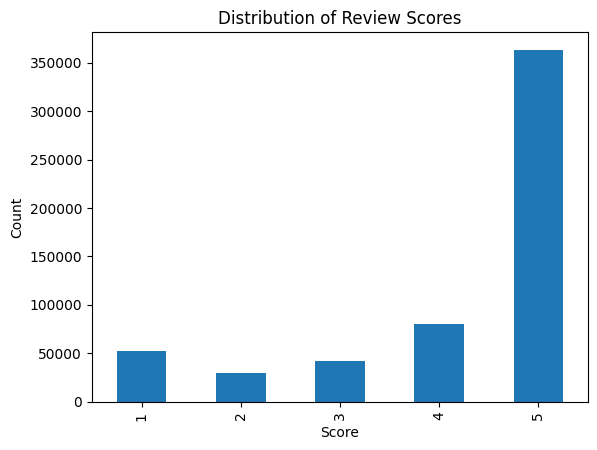

In [ ]:
reviews['Score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

In [ ]:
reviews = reviews[[
    'ProductId', 'UserId', 'Score', 'Summary', 'Text',
    'HelpfulnessNumerator', 'HelpfulnessDenominator'
]].copy()

In [ ]:
reviews.dropna(subset=['Summary', 'Text'], inplace=True)

reviews = reviews[
    (reviews['Summary'].astype(str).str.strip() != '') &
    (reviews['Text'].astype(str).str.strip() != '')
]

print(reviews.shape)

(568427, 7)


In [ ]:
reviews.drop_duplicates(
    subset=['UserId', 'ProductId', 'Text'],
    inplace=True
)

print(reviews.shape)

(567118, 7)


In [ ]:
reviews['full_review'] = reviews['Summary'] + ' ' + reviews['Text']


In [ ]:
reviews['review_length'] = reviews['full_review'].apply(
    lambda x: len(str(x).split())
)

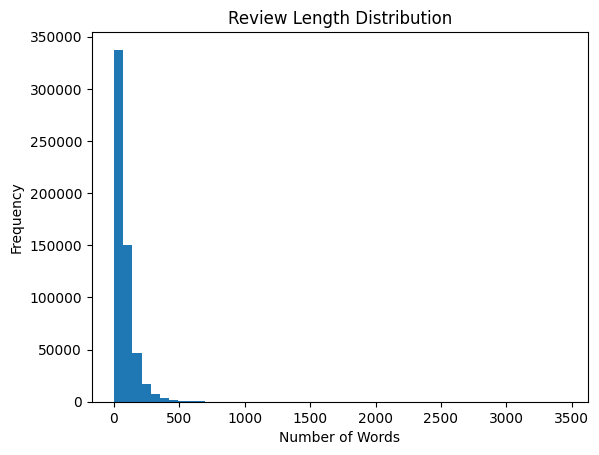

In [ ]:
reviews['review_length'].plot(kind='hist', bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
reviews['summary_length'] = reviews['Summary'].apply(
    lambda x: len(str(x).split())
)

In [ ]:
reviews = reviews[
    (reviews['review_length'] >= 5) &
    (reviews['review_length'] <= 300)
]

In [ ]:
reviews['sentiment'] = reviews['Score'].map({
    1: 'negative',
    2: 'negative',
    3: 'neutral',
    4: 'positive',
    5: 'positive'
})

print(reviews['sentiment'].value_counts())


sentiment
positive    433801
negative     79667
neutral      41149
Name: count, dtype: int64


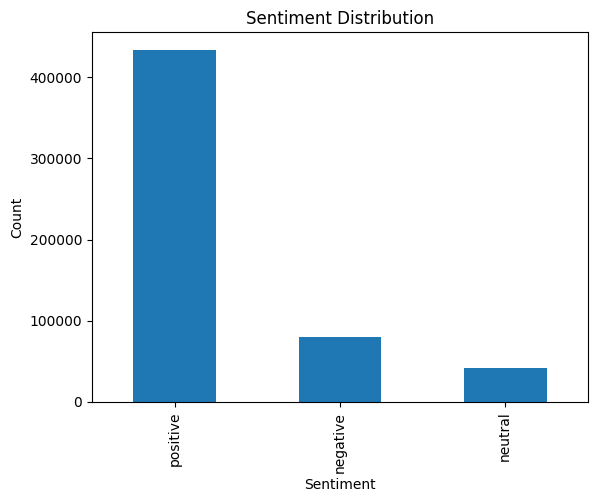

In [ ]:
reviews['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))

for word in ['not', 'no', 'never']:
    if word in stop_words:
        stop_words.remove(word)

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = str(text).lower()

    text = contractions.fix(text)

    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\\S+|www\\S+', ' ', text)
    text = re.sub(r'\\S+@\\S+', ' ', text)
    text = re.sub(r'\\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()

    return text

In [ ]:
def handle_negation(text):
    words = text.split()
    result = []

    i = 0
    while i < len(words):
        if words[i] in ['not', 'no', 'never'] and i + 1 < len(words):
            result.append(words[i] + '_' + words[i + 1])
            i += 2
        else:
            result.append(words[i])
            i += 1

    return ' '.join(result)

In [ ]:
def preprocess_text(text):
    text = clean_text(text)
    text = handle_negation(text)

    tokens = word_tokenize(text)

    final_words = []

    for word in tokens:
        if word not in stop_words:
            final_words.append(lemmatizer.lemmatize(word))

    return ' '.join(final_words)

In [ ]:
reviews['clean_review'] = reviews['full_review'].apply(preprocess_text)
reviews['llm_review'] = reviews['full_review'].apply(clean_text)

In [ ]:
reviews = reviews[reviews['clean_review'].astype(str).str.strip() != '']

In [ ]:
all_words = ' '.join(reviews['clean_review']).split()
word_freq = Counter(all_words)

In [ ]:
rare_words = {
    word for word, count in word_freq.items()
    if count < 2
}

In [ ]:
reviews['clean_review'] = reviews['clean_review'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in rare_words])
)

In [ ]:
reviews = reviews[
    reviews['clean_review'].astype(str).str.strip() != ''
]

In [ ]:
reviews['has_exclamation'] = reviews['full_review'].str.contains('!').astype(int)

reviews['helpfulness_ratio'] = np.where(
    reviews['HelpfulnessDenominator'] > 0,
    reviews['HelpfulnessNumerator'] / reviews['HelpfulnessDenominator'],
    0
)

In [ ]:
for i in range(3):
    print('Original:')
    print(reviews.iloc[i]['full_review'])

    print('\nCleaned:')
    print(reviews.iloc[i]['clean_review'])

Original:
Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned:
good quality dog food bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better
Original:
Not as Advertised Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

Cleaned:
not_as advertised product arrived labeled jumbo salted peanut peanut actually small sized unsalted not_sure error vendor intended represent product jumbo
Original:
"Delight" says it all This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelat

In [ ]:
reviews.to_csv('/content/clean_reviews.csv', index=False)

print('Saved Successfully')

Saved Successfully


# Feature Extraction

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(reviews['sentiment'])

# Split BEFORE TF-IDF (avoid data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    reviews['clean_review'],
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

In [ ]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

# Balancing
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

# Class names (for reports)
class_names = le.classes_

In [ ]:
'''#TF-IDF
X = reviews['clean_review']
y = reviews['sentiment']

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)
X_tfidf = tfidf.fit_transform(X)'''

"#TF-IDF\nX = reviews['clean_review']\ny = reviews['sentiment']\n\ntfidf = TfidfVectorizer(\n    max_features=20000,\n    ngram_range=(1, 2),\n    sublinear_tf=True,\n    min_df=3\n)\nX_tfidf = tfidf.fit_transform(X)"

In [ ]:
'''#Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

#Balancing
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

# Labels
le = LabelEncoder()
y_res_enc = le.fit_transform(y_res)
y_test_enc = le.transform(y_test)
class_names = le.classes_'''

'#Split\nX_train, X_test, y_train, y_test = train_test_split(\n    X_tfidf, y, test_size=0.2, random_state=42, stratify=y\n)\n\n#Balancing\nros = RandomOverSampler(random_state=42)\nX_res, y_res = ros.fit_resample(X_train, y_train)\n\n# Labels\nle = LabelEncoder()\ny_res_enc = le.fit_transform(y_res)\ny_test_enc = le.transform(y_test)\nclass_names = le.classes_'

# Training Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=10),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
}

results = {}

for name, model in models.items():
    print(f"\n Training {name}...")

    model.fit(X_res, y_res)
    y_pred = model.predict(X_test)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model': model,
        'acc': acc,
        'f1': f1,
        'cm': confusion_matrix(y_test, y_pred)
    }

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")


 Training Logistic Regression...

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.82      0.80     15933
     neutral       0.39      0.69      0.50      8230
    positive       0.98      0.90      0.94     86761

    accuracy                           0.87    110924
   macro avg       0.71      0.80      0.74    110924
weighted avg       0.91      0.87      0.88    110924

Logistic Regression → Accuracy: 0.8702, F1: 0.8831

 Training Linear SVM...

Linear SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.83      0.79     15933
     neutral       0.39      0.69      0.50      8230
    positive       0.98      0.89      0.93     86761

    accuracy                           0.87    110924
   macro avg       0.71      0.80      0.74    110924
weighted avg       0.90      0.87      0.88    110924

Linear SVM → Accuracy: 0.8678, F1: 0.8808

 Train

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:58:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

In [ ]:
names = list(results.keys())
accs = [results[m]['acc'] for m in names]
f1s = [results[m]['f1'] for m in names]

x = np.arange(len(names))
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, accs, 0.4, label='Accuracy', color='skyblue')
plt.bar(x + 0.2, f1s, 0.4, label='F1 Score', color='salmon')
plt.xticks(x, names)
plt.title(" Model Comparison: Accuracy vs F1 Score")
plt.legend()
plt.show()

In [ ]:
import seaborn as sns

for name, r in results.items():
    plt.figure(figsize=(5,4))

    sns.heatmap(
        r['cm'],
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
import joblib

# Choose best model based on F1-score
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']

print(f"\n Best Model: {best_model_name}")
print(f"F1 Score: {results[best_model_name]['f1']:.4f}")

# Save model + vectorizer + encoder
joblib.dump(best_model, 'best_ml_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("\n Saved: best_ml_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")


 Best Model: Logistic Regression
F1 Score: 0.8831

 Saved: best_ml_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl


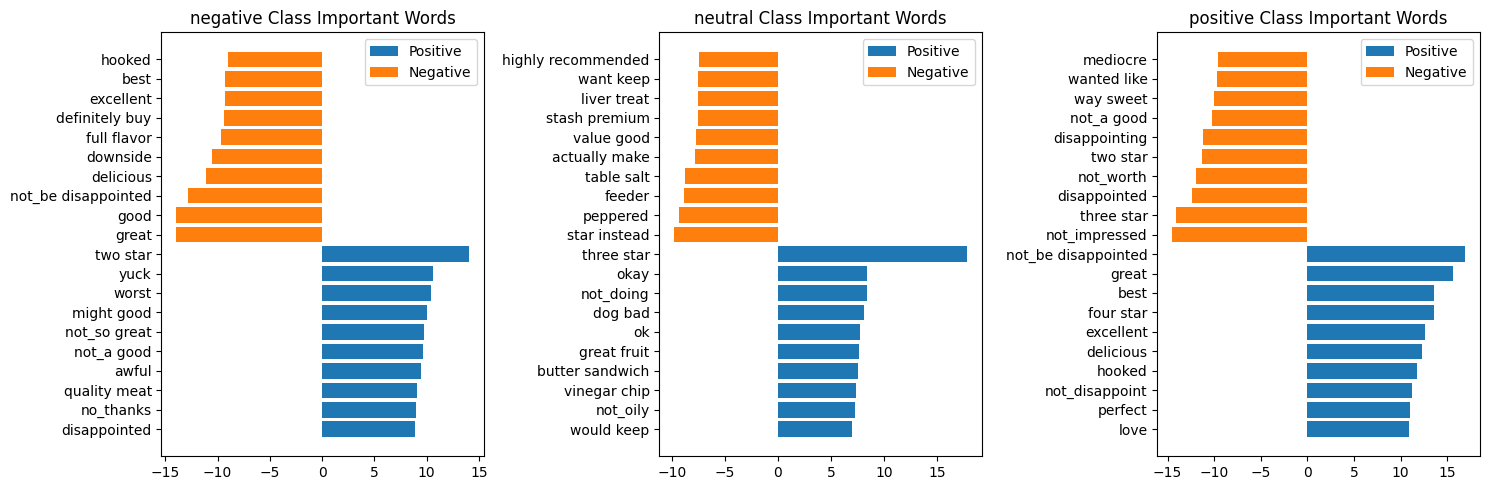

In [ ]:
plt.figure(figsize=(15, 5))

feature_names = tfidf.get_feature_names_out()
lr_model = results['Logistic Regression']['model']

for i, cls in enumerate(class_names):
    coefs = lr_model.coef_[i]

    # Top positive words
    top_pos = np.argsort(coefs)[-10:]
    pos_words = [feature_names[j] for j in top_pos]
    pos_weights = coefs[top_pos]

    # Top negative words
    top_neg = np.argsort(coefs)[:10]
    neg_words = [feature_names[j] for j in top_neg]
    neg_weights = coefs[top_neg]

    plt.subplot(1, len(class_names), i+1)

    # Plot
    plt.barh(pos_words, pos_weights, label="Positive")
    plt.barh(neg_words, neg_weights, label="Negative")

    plt.title(f"{cls} Class Important Words")
    plt.legend()

plt.tight_layout()
plt.show()

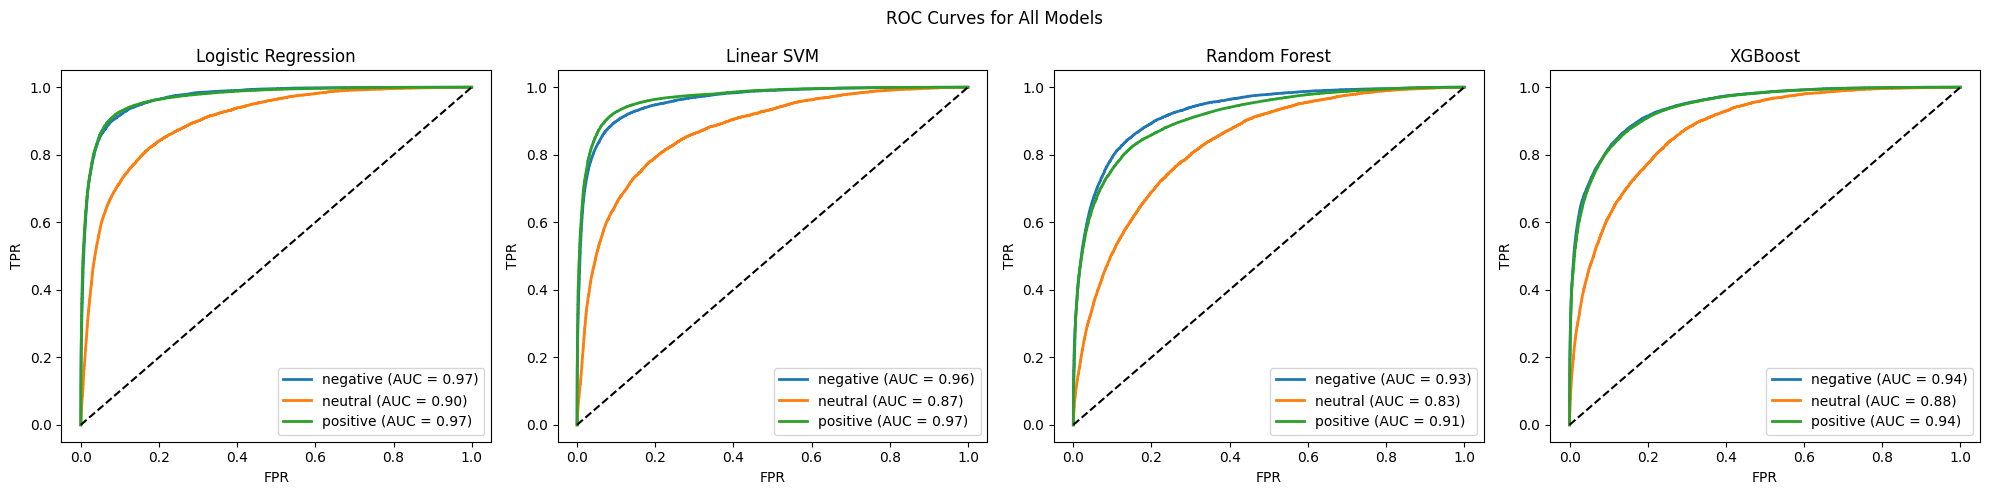

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
n_classes = len(class_names)

fig, axes = plt.subplots(1, len(results), figsize=(20, 5))

if len(results) == 1:
    axes = [axes]

for i, (name, r) in enumerate(results.items()):
    ax = axes[i]
    model = r['model']

    # Get scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, lw=2, label=f"{class_names[j]} (AUC = {roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(name)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()

plt.suptitle("ROC Curves for All Models")
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(models['Logistic Regression'], 'best_ml_model.pkl')
print("\n Saved: tfidf_vectorizer.pkl & best_ml_model.pkl")


 Saved: tfidf_vectorizer.pkl & best_ml_model.pkl


#  Deep Learning for Sentiment Analysis
### Continuation from ML Baseline

Now that we've built solid ML baselines (Logistic Regression, SVM, Random Forest, XGBoost), it's time to go deeper. In this section we'll:

- Build and compare **3 deep learning architectures**: LSTM, GRU, and CNN
- Generate **neural embeddings using embedding layers** to capture semantic meaning of reviews
- Do proper train/val/test splits with early stopping
- Visualize training curves, confusion matrices, and performance comparison
- Compare everything against ML models

##  Deep Learning - Embedding Representation

In [ ]:
! pip install tensorflow transformers -q

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import AutoTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from transformers import AutoModel, AutoTokenizer

2026-04-19 13:40:08.433796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776606008.628834      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776606008.685748      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776606009.128155      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776606009.128184      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776606009.128187      55 computation_placer.cc:177] computation placer alr

In [ ]:
max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews['clean_review'])

X_seq = tokenizer.texts_to_sequences(reviews['clean_review'])
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post')

# Labels
y_dl = le.transform(reviews['sentiment'])


In [ ]:
from sklearn.model_selection import train_test_split

X_train_dl, X_temp_dl, y_train_dl, y_temp_dl = train_test_split(
    X_pad, y_dl, test_size=0.2, random_state=42, stratify=y_dl
)

X_val_dl, X_test_dl, y_val_dl, y_test_dl = train_test_split(
    X_temp_dl, y_temp_dl, test_size=0.5, random_state=42, stratify=y_temp_dl
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Neural Embedding Representation


# The embedding layer converts words into dense vectors
# instead of sparse representations like TF-IDF.

# This allows the model to learn:
# - Semantic meaning of words
# - Context between words
# - Similarity between reviews

embedding_dim = 128

In [ ]:
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len
    ),

    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = lstm_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1776606071.278791      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/20


I0000 00:00:1776606075.215143     244 cuda_dnn.cc:529] Loaded cuDNN version 91002


3467/3467 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.8115 - loss: 0.5657 - val_accuracy: 0.8876 - val_loss: 0.2991
Epoch 2/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.8986 - loss: 0.2652 - val_accuracy: 0.9031 - val_loss: 0.2666
Epoch 3/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9219 - loss: 0.2139 - val_accuracy: 0.9145 - val_loss: 0.2407
Epoch 4/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9375 - loss: 0.1754 - val_accuracy: 0.9154 - val_loss: 0.2427
Epoch 5/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9491 - loss: 0.1453 - val_accuracy: 0.9184 - val_loss: 0.2439
Epoch 6/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9590 - loss: 0.1216 - val_accuracy: 0.9207 - val_loss: 0.2572


In [ ]:
# Extract learned embedding weights
embedding_layer = lstm_model.layers[0]
embedding_weights = embedding_layer.get_weights()[0]

print("Embedding matrix shape:", embedding_weights.shape)

Embedding matrix shape: (20000, 128)


We used an Embedding layer to transform words into dense vector representations.
Unlike TF-IDF, embeddings capture semantic relationships between words,
allowing the model to understand context and similarity between reviews.

These learned representations improve the performance of sequential models
such as LSTM and GRU.

In [ ]:
gru_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len
    ),
    GRU(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru = gru_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.8256 - loss: 0.5204 - val_accuracy: 0.9043 - val_loss: 0.2551
Epoch 2/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9168 - loss: 0.2284 - val_accuracy: 0.9201 - val_loss: 0.2269
Epoch 3/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9372 - loss: 0.1766 - val_accuracy: 0.9214 - val_loss: 0.2273
Epoch 4/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9519 - loss: 0.1389 - val_accuracy: 0.9233 - val_loss: 0.2295
Epoch 5/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9634 - loss: 0.1088 - val_accuracy: 0.9240 - val_loss: 0.2657


In [ ]:
cnn_model = Sequential([
     Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len
    ),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/20


I0000 00:00:1776606556.914213     245 service.cc:152] XLA service 0x7c06240057d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776606556.914254     245 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  36/3467 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7058 - loss: 0.8758 

I0000 00:00:1776606559.990866     245 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3467/3467 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.8532 - loss: 0.4072 - val_accuracy: 0.9038 - val_loss: 0.2668
Epoch 2/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9083 - loss: 0.2483 - val_accuracy: 0.9108 - val_loss: 0.2480
Epoch 3/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9284 - loss: 0.1973 - val_accuracy: 0.9157 - val_loss: 0.2414
Epoch 4/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9403 - loss: 0.1655 - val_accuracy: 0.9166 - val_loss: 0.2449
Epoch 5/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9496 - loss: 0.1403 - val_accuracy: 0.9179 - val_loss: 0.2583
Epoch 6/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9563 - loss: 0.1221 - val_accuracy: 0.9184 - val_loss: 0.2690


In [ ]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),

    Bidirectional(LSTM(64)),

    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

bilstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history_bilstm = bilstm_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step - accuracy: 0.8719 - loss: 0.3546 - val_accuracy: 0.9088 - val_loss: 0.2492
Epoch 2/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.9178 - loss: 0.2242 - val_accuracy: 0.9165 - val_loss: 0.2325
Epoch 3/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.9346 - loss: 0.1822 - val_accuracy: 0.9209 - val_loss: 0.2251
Epoch 4/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.9462 - loss: 0.1514 - val_accuracy: 0.9235 - val_loss: 0.2303
Epoch 5/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.9562 - loss: 0.1253 - val_accuracy: 0.9242 - val_loss: 0.2430
Epoch 6/20
3467/3467 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.9637 - loss: 0.1057 - val_accuracy: 0.9220 - val_loss: 0.2648


In [ ]:
# Evaluation Function

def evaluate_dl_model(model, name):
    y_pred = model.predict(X_test_dl)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test_dl, y_pred_classes, target_names=class_names))

    acc = accuracy_score(y_test_dl, y_pred_classes)
    f1 = f1_score(y_test_dl, y_pred_classes, average='weighted')

    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} F1 Score: {f1:.4f}")

    return acc, f1

In [ ]:
dl_results = {}

dl_results['LSTM'] = evaluate_dl_model(lstm_model, "LSTM")
dl_results['GRU'] = evaluate_dl_model(gru_model, "GRU")
dl_results['CNN'] = evaluate_dl_model(cnn_model, "CNN")
dl_results['BILSTM'] = evaluate_dl_model(bilstm_model, "BILSTM")

1734/1734 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.86      0.83      7967
     neutral       0.62      0.41      0.49      4115
    positive       0.95      0.97      0.96     43380

    accuracy                           0.92     55462
   macro avg       0.79      0.75      0.76     55462
weighted avg       0.91      0.92      0.91     55462

LSTM Accuracy: 0.9153
LSTM F1 Score: 0.9101
1734/1734 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

GRU Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.83      0.84      7967
     neutral       0.60      0.50      0.54      4115
    positive       0.96      0.97      0.97     43380

    accuracy                           0.92     55462
   macro avg       0.80      0.77      0.78     55462
weighted avg       0.91      0.92      0.92     55462

GRU Accuracy: 0.9189
GRU F1 Score: 0.9161
1734/1734

In [ ]:
y_pred = lstm_model.predict(X_test_dl)
y_pred_classes = np.argmax(y_pred, axis=1)

1734/1734 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


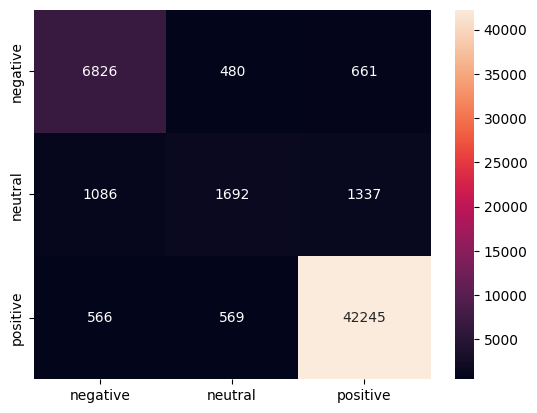

In [ ]:
sns.heatmap(
    confusion_matrix(y_test_dl, y_pred_classes),
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.show()

In [ ]:
print("\n===== FINAL COMPARISON =====")

for name, r in results.items():
    print(f"{name} → Acc: {r['acc']:.4f}, F1: {r['f1']:.4f}")

for name, (acc, f1) in dl_results.items():
    print(f"{name} → Acc: {acc:.4f}, F1: {f1:.4f}")


===== FINAL COMPARISON =====
Logistic Regression → Acc: 0.8707, F1: 0.8834
Linear SVM → Acc: 0.8677, F1: 0.8807
Random Forest → Acc: 0.7855, F1: 0.8107
XGBoost → Acc: 0.7903, F1: 0.8158
LSTM → Acc: 0.9153, F1: 0.9101
GRU → Acc: 0.9189, F1: 0.9161
CNN → Acc: 0.9160, F1: 0.9107
BILSTM → Acc: 0.9197, F1: 0.9173


In [ ]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

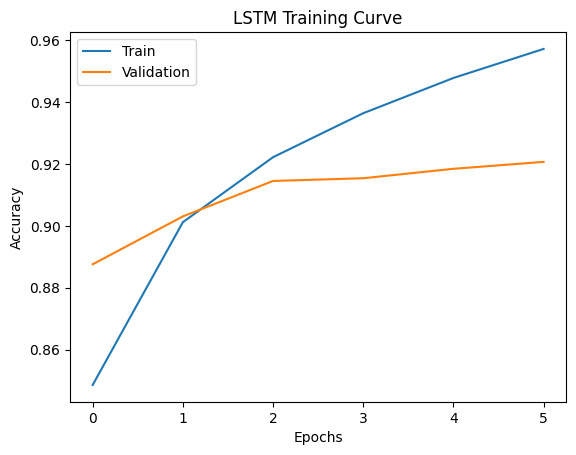

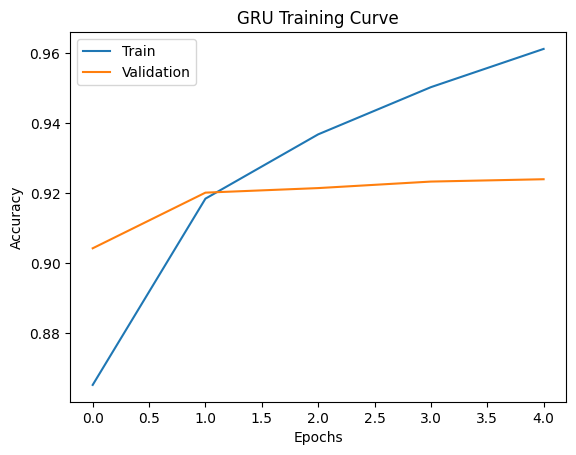

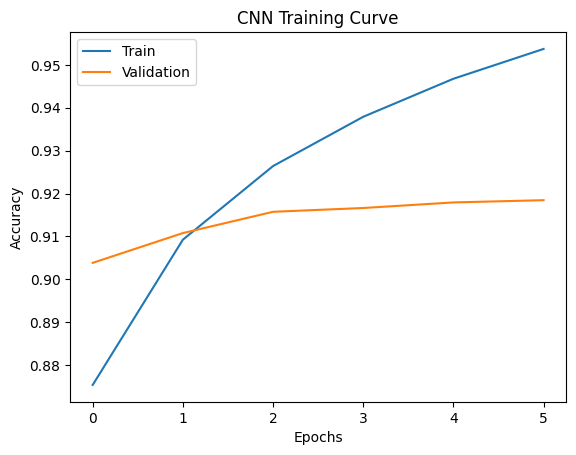

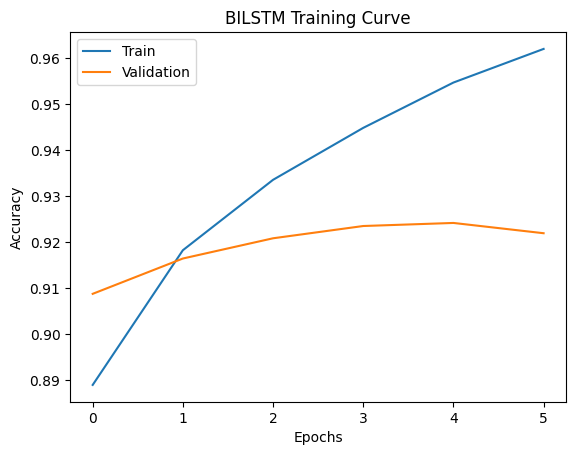

In [ ]:
plot_history(history_lstm, "LSTM Training Curve")
plot_history(history_gru, "GRU Training Curve")
plot_history(history_cnn, "CNN Training Curve")
plot_history(history_bilstm, "BILSTM Training Curve")

> Neural Embedding Representation for Sentiment Understanding + Semantic Features

## **Sentence Embeddings / Semantic Understanding**

> After evaluating both machine learning and deep learning models, we extend our system to semantic representation using sentence embeddings. This enables similarity-based retrieval and forms the foundation for recommendation and RAG systems.

-  Semantic Embeddings + Retrieval Layer
-  Ready for LLM / RAG integration

In [ ]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
# 1. Load Embedding Model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embedding_model = SentenceTransformer(
    'all-MiniLM-L6-v2',
    device='cpu'
)

texts = reviews['clean_review'].tolist()[:3000]

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
# 3. Retrieval Function
def retrieve_similar_documents(query, top_k=5):
    """
    Input: user query (text)
    Output: most semantically similar reviews
    """

    # Convert query to embedding
    query_vec = embedding_model.encode([query])

    # Compute similarity
    similarities = cosine_similarity(query_vec, embeddings)[0]

    # Get top-k results
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = reviews.iloc[top_indices][
        ['clean_review', 'sentiment']
    ].copy()

    results['similarity_score'] = similarities[top_indices][::-1]

    return results


In [ ]:
# 4. Example Test

query = "This movie was amazing with great acting and story"

results = retrieve_similar_documents(query)

print(results)

                                           clean_review sentiment  \
2860  addicted addicted know movie harry met sally d...  positive   
1964  absolutely wonderful family favorite really un...  positive   
2936  amazing got mention ny time immediately became...  positive   
1183  loved bought lollipop daughter rd birthday sup...  positive   
1694  yummy healthy snack tried chip hotel stayed lo...  positive   

      similarity_score  
2860          0.266840  
1964          0.280083  
2936          0.306174  
1183          0.339566  
1694          0.406632  


> I focused on building the representation and retrieval layers using ML, DL, and semantic embeddings, which serve as the backbone for downstream LLM and RAG integration.

#LLM

I used a Large Language Model (LLM) to analyze and interpret customer reviews.

Given a product query, it retrieves relevant reviews and applies LLM-based reasoning to:

- Summarize overall customer opinions
- Extract key pros and cons
- Answer user questions based on review content

In [ ]:
!pip install groq -q
print("✅ Groq installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.4 MB/s eta 0:00:00
✅ Groq installed!


In [ ]:
from groq import Groq
import pandas as pd

GROQ_API_KEY = "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"

client = Groq(api_key=GROQ_API_KEY)
MODEL = "llama-3.3-70b-versatile"

print(f"Groq ready : {MODEL}")

Groq ready : llama-3.3-70b-versatile


In [ ]:

def call_llm(system_prompt: str, user_message: str, temperature: float = 0.3) -> str:

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message}
        ],
        temperature=temperature,
        max_tokens=1024
    )

    return response.choices[0].message.content

print("LLM helper function ready!")

LLM helper function ready!


In [ ]:


test_response = call_llm(
    system_prompt="You are a helpful assistant.",
    user_message="Say hello in one sentence."
)

print(" groq Response:")
print(test_response)

 groq Response:
Hello, it's nice to meet you and I'm here to help with any questions or tasks you may have.


In [ ]:
import pandas as pd

# Load the preprocessed reviews data
reviews = pd.read_csv('/content/clean_reviews.csv')

def summarize_reviews(reviews_list: list, product_name: str = "this product") -> str:

    combined_reviews = "\n---\n".join(reviews_list[:15])

    system_prompt = """
    You are an expert product analyst.
    Your job is to read customer reviews and provide clear, objective summaries.
    Always be concise, factual, and helpful.
    """

    user_message = f"""
    Here are customer reviews for {product_name}:

    {combined_reviews}

    Please provide a concise summary (3-4 sentences) of what customers think about this product.
    Focus on the most mentioned points. Be objective.
    """

    return call_llm(system_prompt, user_message)


sample_reviews = reviews['Text'].dropna().head(15).tolist()

print(" Generating summary...\n")
summary = summarize_reviews(sample_reviews, product_name="Amazon Food Products")

print(" Summary:")
print(summary)

 Generating summary...

 Summary:
Customers have expressed satisfaction with various Amazon food products, including pet food, candies, and condiments. Many reviewers praised the quality and flavor of the products, such as the Vitality canned dog food, saltwater taffy, and Tequila Picante Gourmet de Inclan hot sauce. Some customers noted issues with product labeling or formula changes, which affected their pets' acceptance of the food. Overall, customers appreciated the taste, freshness, and value of the products, with some becoming repeat buyers or recommending them to others.


In [ ]:
def extract_pros_cons(reviews_list: list, product_name: str = "this product") -> dict:

    combined_reviews = "\n---\n".join(reviews_list[:15])

    system_prompt = """
    You are a product review analyst.
    Extract the main pros and cons from customer reviews.
    Return ONLY in this exact format, nothing else:

    PROS:
    - [pro 1]
    - [pro 2]
    - [pro 3]

    CONS:
    - [con 1]
    - [con 2]
    - [con 3]
    """

    user_message = f"""
    Reviews for {product_name}:

    {combined_reviews}

    Extract the top pros and cons (max 5 each) based on what customers mention most.
    """

    raw_output = call_llm(system_prompt, user_message, temperature=0.2)

    pros, cons = [], []
    current_section = None

    for line in raw_output.split("\n"):
        line = line.strip()
        if "PROS:" in line.upper():
            current_section = "pros"
        elif "CONS:" in line.upper():
            current_section = "cons"
        elif line.startswith("-") and current_section == "pros":
            pros.append(line[1:].strip())
        elif line.startswith("-") and current_section == "cons":
            cons.append(line[1:].strip())

    return {"pros": pros, "cons": cons, "raw": raw_output}


print(" Extracting Pros & Cons...\n")
result = extract_pros_cons(sample_reviews, "Amazon Food Products")

print("PROS:")
for p in result['pros']:
    print(f" {p}")

print("\n CONS:")
for c in result['cons']:
    print(f" {c}")

 Extracting Pros & Cons...

PROS:
 Good quality products
 Great taste and flavor
 Soft and chewy texture (for taffy)
 Healthy ingredients (for dog food)
 Fast and secure delivery

 CONS:
 Incorrect product labeling (e.g. wrong size or type)
 Formula changes affecting pet preference
 Some flavors not liked by customers (e.g. red/black licorice)
 Medicinal taste (for some products)
 Products not meeting expectations (e.g. stale food)


In [ ]:
def answer_product_question(question: str, reviews_list: list, product_name: str = "this product") -> str:

    combined_reviews = "\n---\n".join(reviews_list[:15])

    system_prompt = """
    You are a helpful and concise product advisor.
    Answer the user's question about the product based ONLY on the provided reviews.
    If the information is not available in the reviews, state that you don't know.
    """

    user_message = f"""
    Reviews for {product_name}:

    {combined_reviews}

    Question: {question}

    Answer concisely:
    """

    return call_llm(system_prompt, user_message, temperature=0.1)

def smart_product_advisor(product_query: str, df: pd.DataFrame, question: str = None):

    print(f"🔍 Searching for: '{product_query}'")

    mask = (
        df['Summary'].str.contains(product_query, case=False, na=False) |
        df['Text'].str.contains(product_query, case=False, na=False)
    )
    filtered = df[mask].head(20)

    if filtered.empty:
        print(f"No reviews found. Using general sample.")
        filtered = df.head(20)

    print(f"Found {len(filtered)} relevant reviews")

    reviews_list = filtered['Text'].dropna().tolist()

    print("\n" + "=" * 60)
    print(f"AI Smart Product Advisor — {product_query}")
    print("=" * 60)

    print("\nSUMMARY")
    print("-" * 40)
    summary = summarize_reviews(reviews_list, product_query)
    print(summary)

    print("\n PROS & CONS")
    print("-" * 40)
    pc = extract_pros_cons(reviews_list, product_query)

    print("Pros:")
    for p in pc['pros']:
        print(f" {p}")

    print("\nCons:")
    for c in pc['cons']:
        print(f" {c}")

    if question:
        print(f"\n YOUR QUESTION: {question}")
        print("-" * 40)
        answer = answer_product_question(question, reviews_list, product_query)
        print(f" groq: {answer}")

    print("\n" + "=" * 60)

    return {
        "product": product_query,
        "reviews_found": len(filtered),
        "summary": summary,
        "pros": pc['pros'],
        "cons": pc['cons'],
    }

print(" Complete pipeline ready!")

 Complete pipeline ready!


In [ ]:
result = smart_product_advisor(
    product_query="coffee",
    df=reviews,
    question="Is this coffee worth buying for daily use?"
)

🔍 Searching for: 'coffee'
Found 20 relevant reviews

AI Smart Product Advisor — coffee

SUMMARY
----------------------------------------
Customers have varied opinions about the coffee products, with some praising their taste and others finding them just average. Many appreciate the convenience and ease of use of certain coffee machines and products, such as the Dolce Gusto. Some customers also value the organic and healthy ingredients in certain coffee products, citing benefits such as smooth flavor and no bitter aftertaste. Overall, customers seem to prioritize taste, convenience, and health benefits when evaluating coffee products.

 PROS & CONS
----------------------------------------
Pros:
 Great taste
 Easy to use
 Good value for the price
 Smooth and rich flavor
 Convenient and fast preparation

Cons:
 Expensive compared to other options
 Not the best quality compared to other brands
 Some products have a "vitaminy" or bitter taste
 Packaging issues with some products
 Not suita

In [ ]:
result2 = smart_product_advisor(
    product_query="chocolate",
    df=reviews,
    question="Would you recommend this as a gift?"
)

🔍 Searching for: 'chocolate'
Found 20 relevant reviews

AI Smart Product Advisor — chocolate

SUMMARY
----------------------------------------
Customers generally enjoy the chocolate products, praising their taste, texture, and variety. Many appreciate the option for sugar-free or low-calorie alternatives that still satisfy their sweet tooth. However, some reviewers experienced issues with melting or grainy texture due to warm weather shipping, highlighting the need for insulated packaging. Overall, customers find the products to be of good quality, but some consider the price to be a bit high, especially when factoring in shipping costs.

 PROS & CONS
----------------------------------------
Pros:
 Great taste and flavor
 Good quality and freshness of the chocolate
 Perfect for those with dietary restrictions or preferences (sugar-free, low calorie)
 Convenient and fun to eat
 Variety of options and combinations available

Cons:
 Melting issues due to warm weather or shipping
 Price c